# Round 010 — T5 value + momentum + quality

ตัวเลขทั้งหมดอ่านจาก `results.csv` ที่ `run.py` ของ round นี้เขียนไว้ · ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023 · ⚠️ survivorship: ราคาของหุ้นที่ออกจากตลาดไปแล้วหายบางส่วน → ผลอาจดูดีเกินจริง · held-out (ตั้งแต่ ก.ค. 2023) ไม่ถูกใช้

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_010/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r010_VMQ_sector_A,0.476,0.640,0.681,0.090,0.125,-0.362,-0.376,False,False,0.0,0.0,63.167,51,1.003,1.137
1,r010_VMQ_sector_Q,0.489,0.625,0.681,0.092,0.124,-0.377,-0.377,False,False,0.0,0.0,64.000,51,0.906,1.108


ผู้เข้ารอบ (S1+S2+S3+S6): []


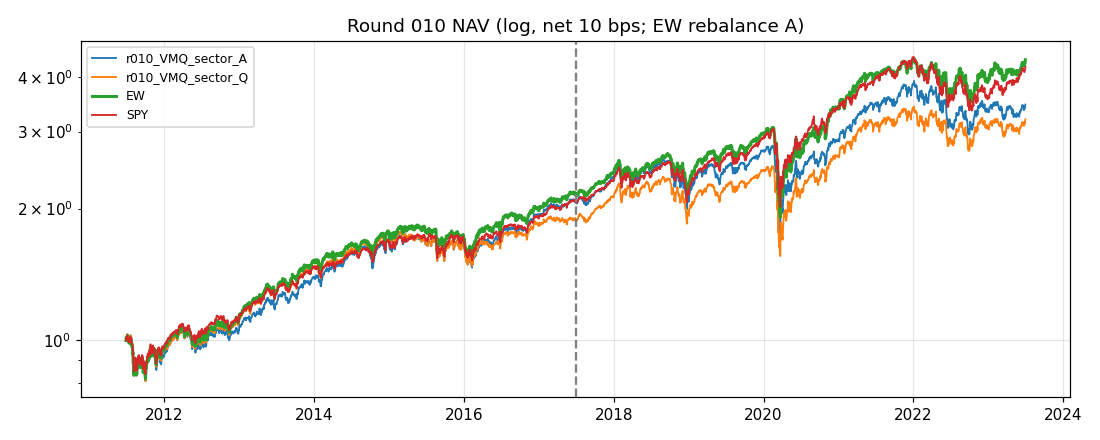

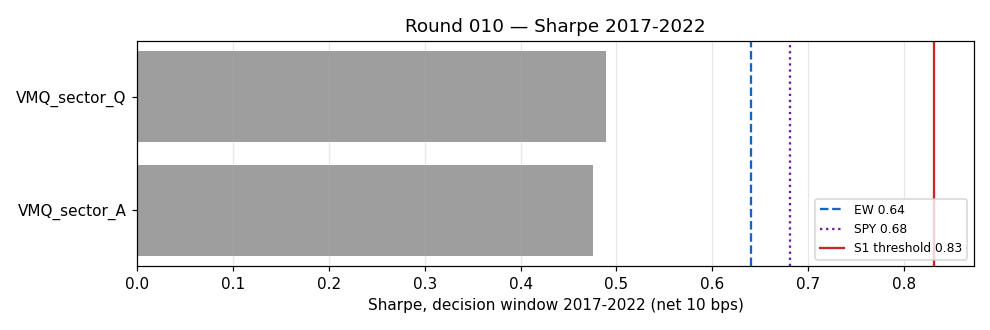

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_010_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_010/RESULTS.md").read_text()))

# Round 010 — EXPLORE2 T5: value + momentum + quality (sector-neutral) — **ไม่มีผู้เข้ารอบ**
2 trial → สะสม 121 · SPY ช่วงตัดสิน Sharpe 0.681

| trial | Sharpe | EW | CAGR (EW) | MaxDD (EW) | S1 | S2 | DSR | ช่วง 2011–16 (EW) |
|---|---|---|---|---|---|---|---|---|
| `r010_VMQ_sector_A` | 0.476 | 0.640 | 9.0% (12.5%) | -36.2% (-37.6%) | False | 0% | 0.000 | 1.003 (1.137) |
| `r010_VMQ_sector_Q` | 0.489 | 0.625 | 9.2% (12.4%) | -37.7% (-37.7%) | False | 0% | 0.000 | 0.906 (1.108) |

แพ้ EW ทั้งสองช่วงและทั้งสองความถี่ (S2 = 0%) — earnings yield (value) ถ่วงผลเหมือนใน round 001–003; การรวมกับ momentum ไม่ได้ทำให้นิ่งขึ้นในหุ้นใหญ่ช่วงนี้
